In [10]:
import sys
import os


module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


from src.models.semi_supervised import run_self_training
from src.models.supervised import train_baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import pandas as pd
import numpy as np

In [11]:

df = pd.read_csv("../data/processed/hotel_prepared.csv")

# 1. Tạo X (features) và y (target)
df_model = pd.get_dummies(df.drop(columns=['lead_time_cat'], errors='ignore'))
X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

# 2. Tạo mask cho semi-supervised (nếu cần dùng cho supervised luôn)
labeled_ratio = 0.2
rng = np.random.RandomState(42)
unlabeled_mask = rng.rand(len(y)) > labeled_ratio

print("Đã khởi tạo xong các biến X, y, và unlabeled_mask.")

Đã khởi tạo xong các biến X, y, và unlabeled_mask.


In [12]:
# Notebook 04: Huấn luyện & So sánh
from src.models.semi_supervised import run_self_training
from src.models.supervised import train_baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 1. Train Supervised (Dùng 20% dữ liệu có nhãn thực tế)
X_labeled = X[~unlabeled_mask]
y_labeled = y[~unlabeled_mask]
model_sup = train_baseline(X_labeled, y_labeled)

# 2. Train Semi-supervised (Tự động hóa hoàn toàn với hàm mới)
model_semi = run_self_training(RandomForestClassifier(), X, y, labeled_ratio=0.2)

# 3. So sánh
print(f"F1 Supervised: {f1_score(y, model_sup.predict(X)):.4f}")
print(f"F1 Semi-supervised: {f1_score(y, model_semi.predict(X)):.4f}")

F1 Supervised: 0.8544
F1 Semi-supervised: 0.8267


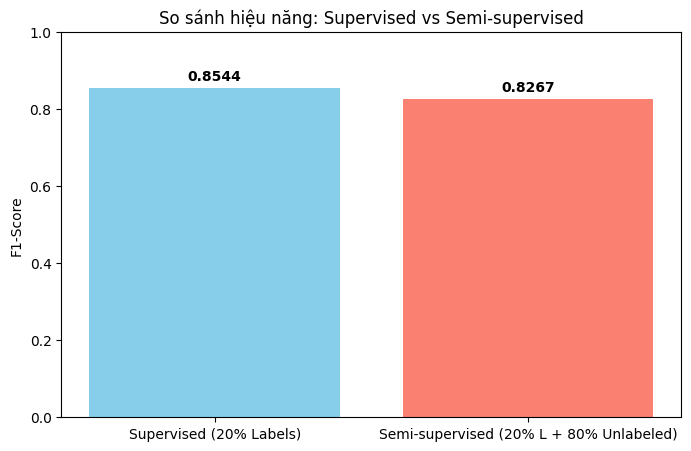

In [13]:
import matplotlib.pyplot as plt

# Dữ liệu cho biểu đồ
labels = ['Supervised (20% Labels)', 'Semi-supervised (20% L + 80% Unlabeled)']
f1_scores = [f1_score(y, model_sup.predict(X)), f1_score(y, model_semi.predict(X))]

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
plt.bar(labels, f1_scores, color=['skyblue', 'salmon'])
plt.ylabel('F1-Score')
plt.title('So sánh hiệu năng: Supervised vs Semi-supervised')
plt.ylim(0, 1) # F1-score nằm trong khoảng 0 đến 1

# Thêm giá trị trên đầu cột
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()